# Acne Classification using Transfer Learning (MobileNetV2)

Notebook ini berisi pipeline training yang telah dioptimalkan untuk klasifikasi jenis jerawat. Masalah overfitting dan ketidakseimbangan kelas ditangani menggunakan **Transfer Learning**, **Class Weighting**, dan **Fine-tuning**.

In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, Sequential, optimizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

## 1. Konfigurasi & Path Dataset

In [2]:
BATCH_SIZE = 32
IMAGE_SIZE = (160, 160)  # Ukuran standar input MobileNetV2
SEED = 42

base_dir = r"../dataset/skin_problem"
train_dir = os.path.join(base_dir, "train")
valid_dir = os.path.join(base_dir, "valid")
test_dir  = os.path.join(base_dir, "test")

## 2. Load Dataset
Kita memuat data langsung dari direktori tanpa melakukan oversampling manual agar tidak terjadi duplikasi data yang menyebabkan overfitting.

In [3]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    label_mode='int',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

valid_ds = tf.keras.preprocessing.image_dataset_from_directory(
    valid_dir,
    label_mode='int',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    label_mode='int',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Classes: {class_names}")

# Simpan nama kelas untuk digunakan di API
with open("class_names.json", "w") as f:
    json.dump(class_names, f)

Found 3650 files belonging to 6 classes.
Found 1548 files belonging to 6 classes.
Found 1545 files belonging to 6 classes.
Classes: ['Blackheads', 'Cyst', 'Papules', 'Pustules', 'Whiteheads', 'darkspots']


## 3. Hitung Class Weights
Memberikan bobot lebih tinggi pada kelas minoritas agar model tidak bias ke kelas mayoritas.

In [4]:
y_train = np.concatenate([y for x, y in train_ds], axis=0)
weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(weights))

print("Bobot kelas untuk menyeimbangkan training:")
for i, name in enumerate(class_names):
    print(f"  {name}: {class_weight_dict[i]:.2f}")

Bobot kelas untuk menyeimbangkan training:
  Blackheads: 0.83
  Cyst: 0.94
  Papules: 0.98
  Pustules: 1.04
  Whiteheads: 3.15
  darkspots: 0.70


## 4. Bangun Model (Transfer Learning)
Menggunakan MobileNetV2 yang sudah dilatih pada ImageNet.

In [5]:
@tf.keras.utils.register_keras_serializable()
def preprocess_input(x):
    return tf.keras.applications.mobilenet_v2.preprocess_input(x)

# Augmentasi data ringan untuk membantu generalisasi
data_augmentation = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
])

# Base model: MobileNetV2
base_model = MobileNetV2(input_shape=IMAGE_SIZE + (3,), include_top=False, weights='imagenet')
base_model.trainable = False  # Bekukan untuk Tahap 1

model = models.Sequential([
    layers.Input(shape=IMAGE_SIZE + (3,)),
    data_augmentation,
    layers.Lambda(preprocess_input),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 5. Training Tahap 1: Feature Extraction

In [6]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=4, min_lr=1e-7, verbose=1)
]

print("Melatih layer kepala...")
history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=30,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

Melatih layer kepala...
Epoch 1/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 23s 173ms/step - accuracy: 0.3868 - loss: 1.5982 - val_accuracy: 0.5872 - val_loss: 1.0675 - learning_rate: 1.0000e-04
Epoch 2/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 19s 168ms/step - accuracy: 0.5244 - loss: 1.2015 - val_accuracy: 0.6227 - val_loss: 0.9486 - learning_rate: 1.0000e-04
Epoch 3/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 19s 168ms/step - accuracy: 0.5636 - loss: 1.0996 - val_accuracy: 0.6382 - val_loss: 0.9050 - learning_rate: 1.0000e-04
Epoch 4/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 19s 163ms/step - accuracy: 0.5921 - loss: 1.0085 - val_accuracy: 0.6486 - val_loss: 0.8802 - learning_rate: 1.0000e-04
Epoch 5/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 19s 162ms/step - accuracy: 0.6145 - loss: 0.9731 - val_accuracy: 0.6738 - val_loss: 0.8240 - learning_rate: 1.0000e-04
Epoch 6/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 18s 157ms/step - accuracy: 0.6225 - loss: 0.9387 - val_accuracy: 0.6796 - val_loss: 0.8197 - learning_rate: 1.0000e-04
Epoch 7/30
115/115 ━━━

## 6. Training Tahap 2: Fine-Tuning
Membuka beberapa layer terakhir dari pre-trained model agar lebih sensitif terhadap fitur spesifik jerawat.

In [7]:
print("Membuka base model untuk fine-tuning...")
base_model.trainable = True

# Bekukan hingga layer 100
for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),  # LR sangat rendah agar tidak merusak bobot pre-trained
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=20,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

Membuka base model untuk fine-tuning...
Epoch 1/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 32s 225ms/step - accuracy: 0.5268 - loss: 1.3576 - val_accuracy: 0.7532 - val_loss: 0.6079 - learning_rate: 1.0000e-05
Epoch 2/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 26s 225ms/step - accuracy: 0.6022 - loss: 1.0145 - val_accuracy: 0.7616 - val_loss: 0.5992 - learning_rate: 1.0000e-05
Epoch 3/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 27s 232ms/step - accuracy: 0.6392 - loss: 0.9101 - val_accuracy: 0.7655 - val_loss: 0.6020 - learning_rate: 1.0000e-05
Epoch 4/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 26s 229ms/step - accuracy: 0.6422 - loss: 0.8715 - val_accuracy: 0.7668 - val_loss: 0.5924 - learning_rate: 1.0000e-05
Epoch 5/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 26s 224ms/step - accuracy: 0.6595 - loss: 0.8289 - val_accuracy: 0.7681 - val_loss: 0.5883 - learning_rate: 1.0000e-05
Epoch 6/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 25s 218ms/step - accuracy: 0.6871 - loss: 0.7710 - val_accuracy: 0.7694 - val_loss: 0.5814 - learning_rate: 1.0000e-05
Epoch 

## 7. Evaluasi Akhir

In [8]:
# Evaluasi pada dataset test
loss, acc = model.evaluate(test_ds)
print(f"Test Accuracy: {acc*100:.2f}%")

y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred = np.argmax(model.predict(test_ds), axis=1)

print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_true, y_pred, target_names=class_names))

# Visualisasi Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

## 8. Plot Kurva Belajar

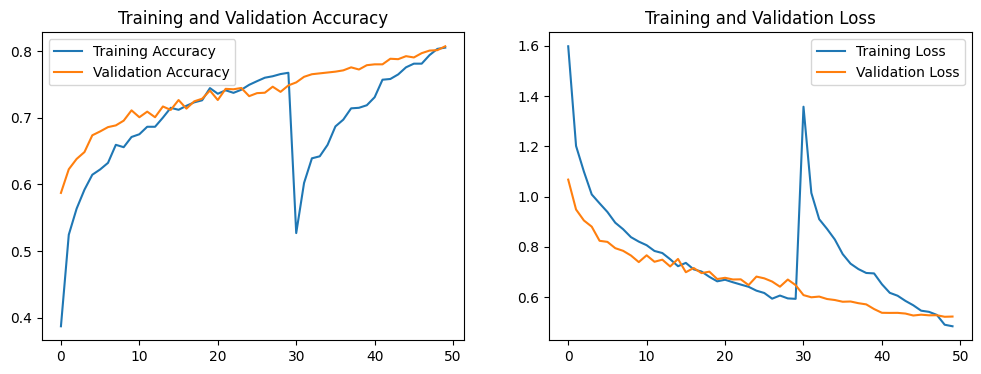

In [9]:
acc_history = history.history['accuracy'] + history_fine.history['accuracy']
val_acc_history = history.history['val_accuracy'] + history_fine.history['val_accuracy']
loss_history = history.history['loss'] + history_fine.history['loss']
val_loss_history = history.history['val_loss'] + history_fine.history['val_loss']

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(acc_history, label='Training Accuracy')
plt.plot(val_acc_history, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss_history, label='Training Loss')
plt.plot(val_loss_history, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

## 9. Simpan Model

In [10]:
model.save("acne_model_final.keras")
print("Model disimpan sebagai acne_model_final.keras")

Model disimpan sebagai acne_model_final.keras
